# Student Stress & Academic Performance — Full EDA
**Fixes applied**: `dropna` bug, `1.1` documentation, `df_fs2` dead code, drop justification, RMSE, overfitting analysis  
**Additions**: correlation heatmap, target distribution, pairplots, feature importance charts, overfitting bar chart, weighted composite scores

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 1. Load Data

In [2]:
df = pd.read_csv("../data/raw/StressLevelDataset_dirty.csv")
print(f"Shape: {df.shape}")
df.head(10)

Shape: (1118, 21)


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,18.0,8.0,1,25.0,3,3.0,Good,5.0,3,1,...,2,1.0,5,2.0,5.0,1.0,NaN,5.0,4.0,High
1,6.0,26.0,0,8.0,1,2.0,Average,2.0,2,4,...,4,4.0,1,4.0,1.0,3.0,2.0,NaN,1.0,Low
2,5.0,25.0,NaN,6.0,1,2.0,Average,1.0,2,4,...,4,4.0,2,NaN,1.0,3.0,2.0,1.0,1.0,Low
3,12.0,23.0,1,10.0,3,1.0,Poor,2.0,2,3,...,2,2.0,3,3.0,3.0,3.0,NaN,3.0,3.0,Medium
4,19.0,15.0,1,27.0,5,NaN,Poor,4.0,5,2,...,2,2.0,5,1.0,4.0,1.0,4.0,5.0,5.0,High
5,3.0,26.0,0,8.0,1,NaN,Average,NaN,2,3,...,5,5.0,2,4.0,1.0,3.0,1.0,1.0,1.0,Low
6,16.0,11.0,false,22.0,5,3.0,Poor,4.0,4,2,...,2,1.0,5,2.0,5.0,1.0,4.0,5.0,5.0,High
7,8.0,28.0,0,4.0,1,2.0,Average,2.0,1,3,...,5,5.0,2,5.0,NaN,3.0,2.0,2.0,1.0,Low
8,12.0,NaN,0,11.0,3,1.0,Poor,2.0,2,3,...,3,3.0,3,2.0,3.0,2.0,2.0,2.0,3.0,Low
9,20.0,14.0,1,NaN,5,NaN,Poor,5.0,4,2,...,2,2.0,4,2.0,NaN,1.0,5.0,NaN,5.0,High


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 1039 non-null   float64
 1   self_esteem                   1049 non-null   float64
 2   mental_health_history         1020 non-null   object 
 3   depression                    1063 non-null   float64
 4   headache                      1118 non-null   int64  
 5   blood_pressure                1008 non-null   float64
 6   sleep_quality                 1028 non-null   object 
 7   breathing_problem             1051 non-null   float64
 8   noise_level                   1118 non-null   int64  
 9   living_conditions             1118 non-null   int64  
 10  safety                        1118 non-null   int64  
 11  basic_needs                   1118 non-null   int64  
 12  academic_performance          1118 non-null   float64
 13  stu

In [4]:
df.describe()

,anxiety_level,self_esteem,depression,headache,blood_pressure,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying
count,1039.000000,1049.000000,1063.000000,1118.000000,1008.000000,1051.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1052.000000,1061.000000,995.000000,1039.000000,1017.000000,1027.000000
mean,11.887392,17.843661,12.921919,2.511628,2.177579,2.764986,2.649374,2.516995,2.727191,2.771914,2.769678,2.626118,2.649240,2.641847,1.887437,2.719923,2.751229,2.605648
std,8.603211,9.413546,8.317868,1.407026,0.875130,1.406431,1.322810,1.115199,1.401430,1.428962,1.402595,1.314378,1.379326,1.517167,1.040137,1.430300,1.404458,1.518337
min,0.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,7.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000
50%,11.000000,19.000000,12.000000,3.000000,2.000000,3.000000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000
75%,17.000000,26.000000,19.000000,3.000000,3.000000,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000
max,92.000000,99.000000,59.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000


## 2. Missing Value Analysis

                              Count  Percent (%)
social_support                  123        11.00
blood_pressure                  110         9.84
extracurricular_activities      101         9.03
mental_health_history            98         8.77
bullying                         91         8.14
sleep_quality                    90         8.05
peer_pressure                    79         7.07
anxiety_level                    79         7.07
self_esteem                      69         6.17
breathing_problem                67         5.99
teacher_student_relationship     66         5.90
future_career_concerns           57         5.10
depression                       55         4.92


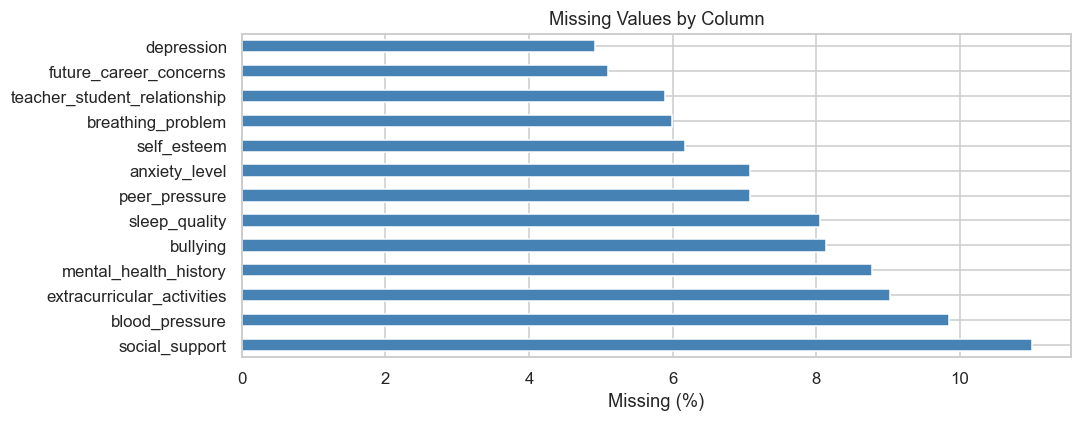

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percent (%)': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False)
print(missing_df)

# Visual
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Percent (%)'].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

## 3. Clean `mental_health_history`

In [6]:
temp = df['mental_health_history'].astype(str).str.strip().str.lower()
print("Unique raw values:", temp.unique())

Unique raw values: ['1' '0' 'nan' 'false' 'n' '1.1' 'y' 'yes' 'true' 'no']


In [7]:
# NOTE: '1.1' is a dirty float that appeared in the raw data — likely a data-entry
# artifact where 1 was entered as 1.1 in a float column before string conversion.
# It is semantically equivalent to 'yes'. Any other unexpected floats (e.g. 0.9, 1.2)
# would fall through to None and be mode-filled; this is logged below.

yes_vals = ['1', 'true', 'yes', 'y']
no_vals  = ['0', 'false', 'no', 'n']
known_dirty = {'1.1': 1}  # document all known dirty mappings here

def map_mhh(x):
    if x in yes_vals:
        return 1
    if x in no_vals:
        return 0
    if x in known_dirty:
        return known_dirty[x]
    print(f"  [WARN] Unrecognised value '{x}' → will be mode-filled")
    return None

temp = temp.apply(map_mhh)

# Fill any remaining NaN with mode
temp.fillna(temp.mode()[0], inplace=True)
df['mental_health_history'] = temp.astype(int)

print("After cleaning:", df['mental_health_history'].unique())
print("NaNs remaining:", df['mental_health_history'].isna().sum())

  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode-filled
  [WARN] Unrecognised value 'nan' → will be mode

## 4. Clean & Encode `sleep_quality` and `stress_level`

In [8]:
print("sleep_quality unique:", df['sleep_quality'].unique())
print("stress_level unique: ", df['stress_level'].unique())

sleep_quality unique: ['Good' 'Average' 'Poor' nan]
stress_level unique:  ['High' 'Low' 'Medium']


In [9]:
# Clean sleep_quality
df['sleep_quality'] = df['sleep_quality'].astype(str).str.strip().str.lower()
df['sleep_quality'].replace('nan', np.nan, inplace=True)

# Conditional imputation: use mode within each stress_level group (context-aware)
df['sleep_quality'] = df.groupby('stress_level')['sleep_quality'].transform(
    lambda x: x.fillna(x.mode()[0])
)

print("NaNs after imputation:", df['sleep_quality'].isna().sum())

NaNs after imputation: 0


In [10]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[
    ['poor', 'average', 'good'],  # sleep_quality: 0, 1, 2
    ['Low', 'Medium', 'High']     # stress_level:  0, 1, 2
])

df[['sleep_quality', 'stress_level']] = encoder.fit_transform(
    df[['sleep_quality', 'stress_level']]
).astype(int)

print("stress_level values:", sorted(df['stress_level'].unique()))
print("sleep_quality values:", sorted(df['sleep_quality'].unique()))

stress_level values: [np.int64(0), np.int64(1), np.int64(2)]
sleep_quality values: [np.int64(0), np.int64(1), np.int64(2)]


## 5. Exploratory Data Analysis

### 5a. Target Distribution

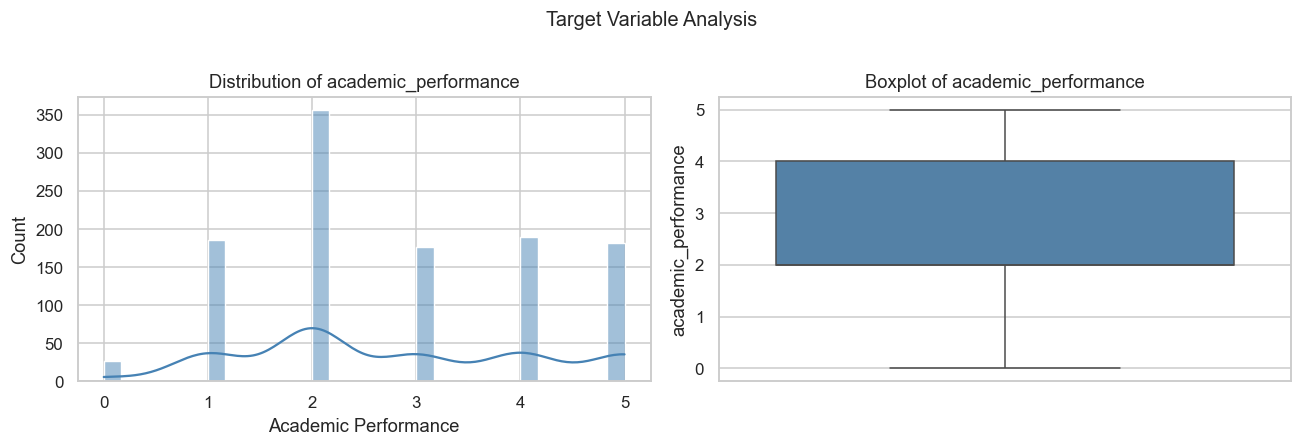

count    1118.000000
mean        2.769678
std         1.402595
min         0.000000
25%         2.000000
50%         2.000000
75%         4.000000
max         5.000000
Name: academic_performance, dtype: float64
Skewness: 0.194


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['academic_performance'], kde=True, ax=axes[0], color='steelblue', bins=30)
axes[0].set_title('Distribution of academic_performance')
axes[0].set_xlabel('Academic Performance')

sns.boxplot(y=df['academic_performance'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot of academic_performance')

plt.suptitle('Target Variable Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(df['academic_performance'].describe())
print(f"Skewness: {df['academic_performance'].skew():.3f}")

### 5b. All Feature Distributions

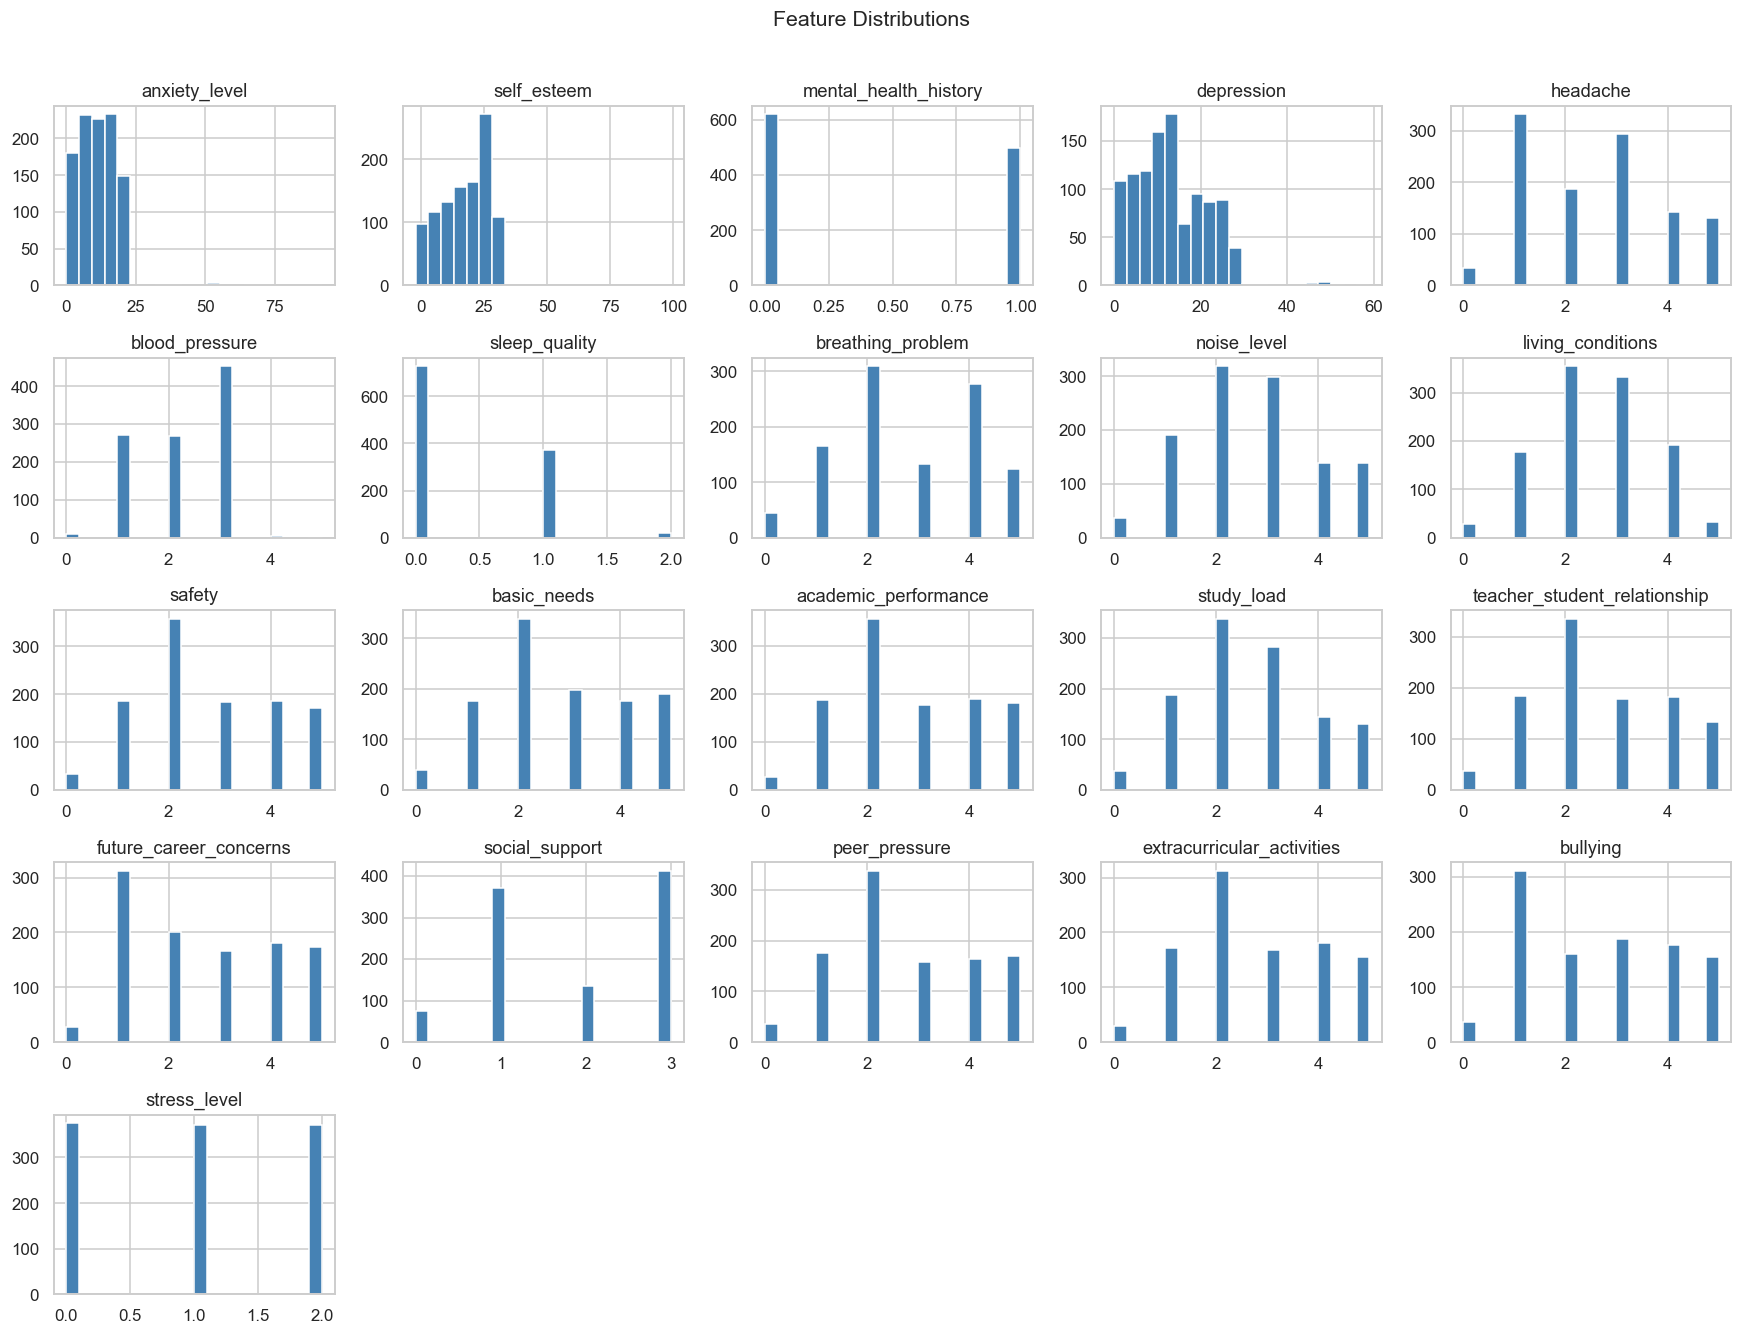

In [12]:
df.hist(figsize=(16, 12), bins=20, edgecolor='white', color='steelblue')
plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 5c. Outlier Detection (Box Plots)

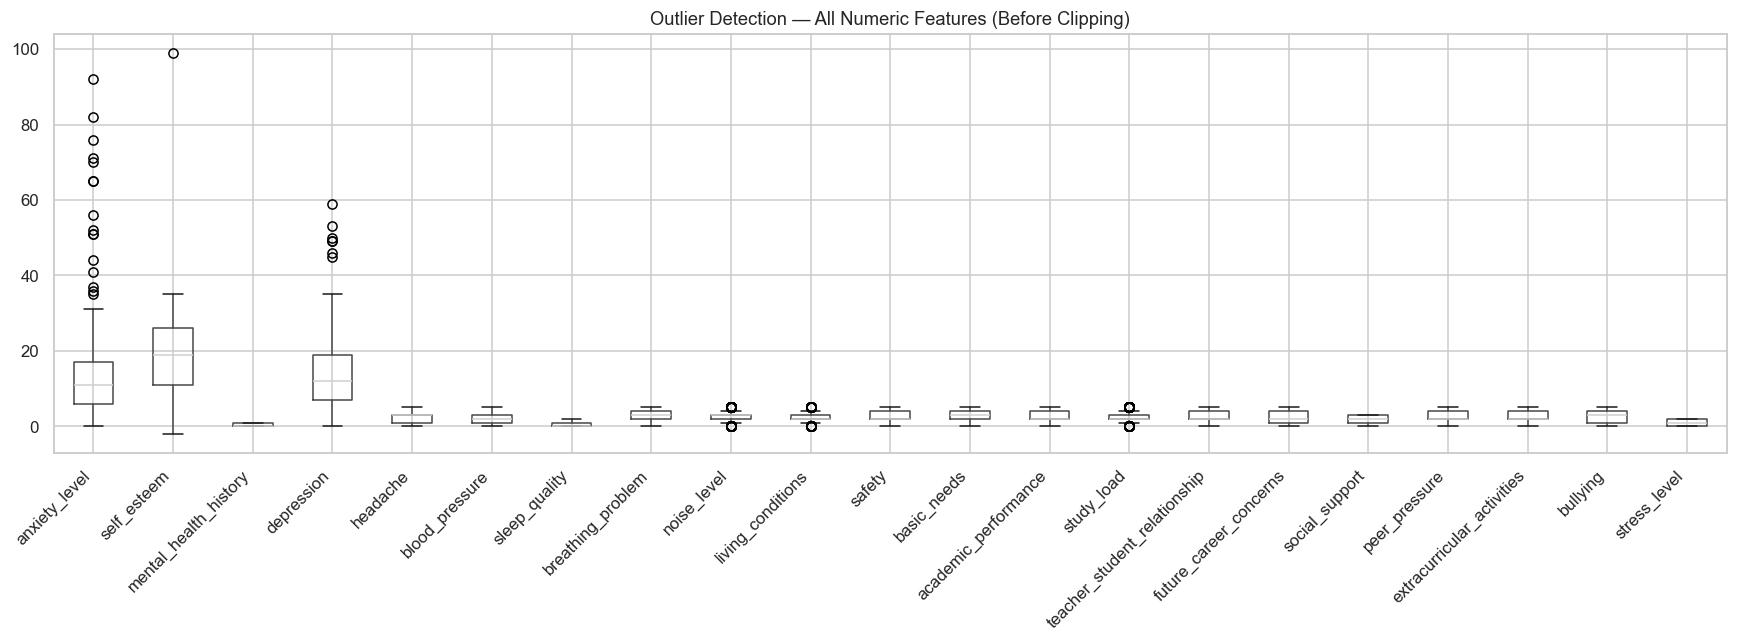

In [13]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

fig, ax = plt.subplots(figsize=(16, 6))
numeric_df.boxplot(ax=ax)
ax.set_title('Outlier Detection — All Numeric Features (Before Clipping)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

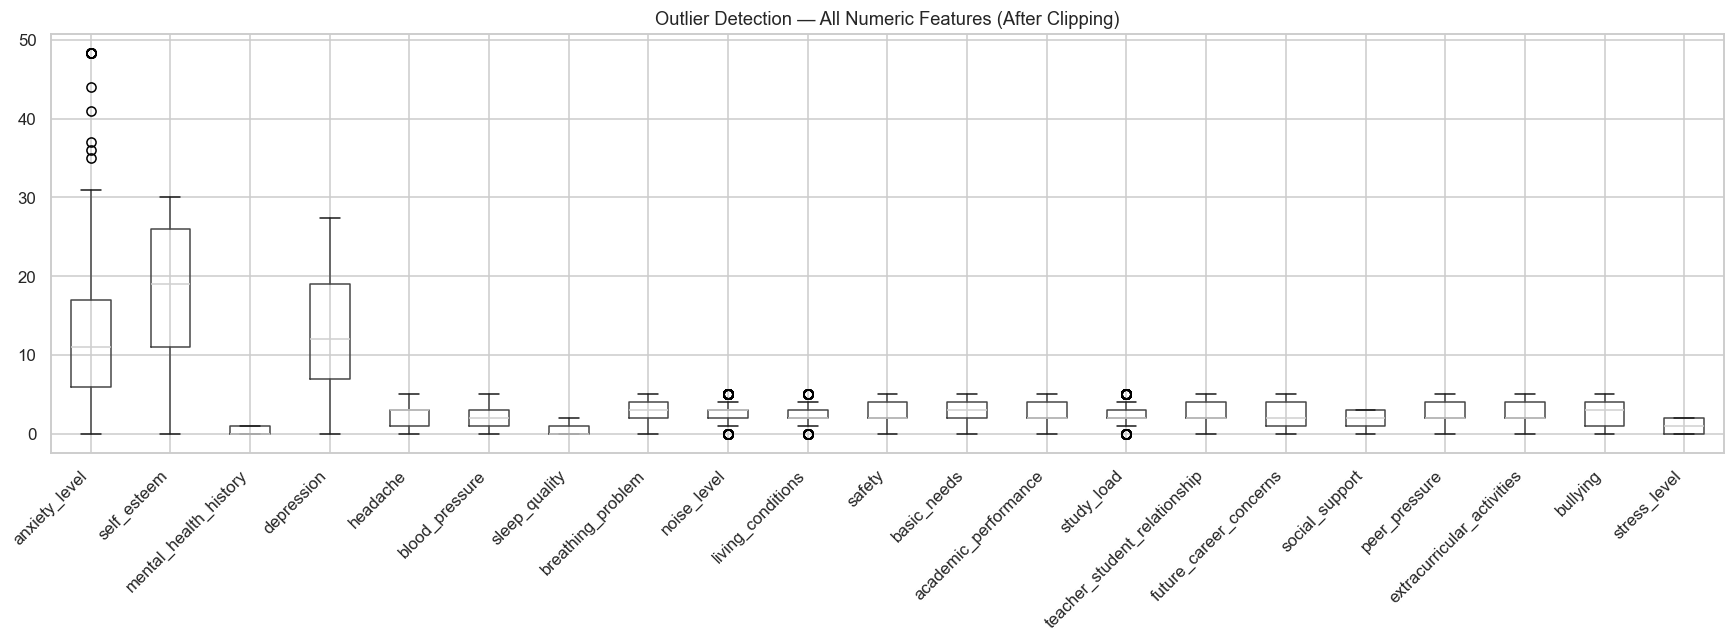

In [14]:
# Clip extreme outliers in continuous columns
for col in ['anxiety_level', 'self_esteem', 'depression']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

numeric_df = df.select_dtypes(include=['int64', 'float64'])
fig, ax = plt.subplots(figsize=(16, 6))
numeric_df.boxplot(ax=ax)
ax.set_title('Outlier Detection — All Numeric Features (After Clipping)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5d. Correlation Heatmap
> Used below to justify which features to drop and which to combine into composite scores.

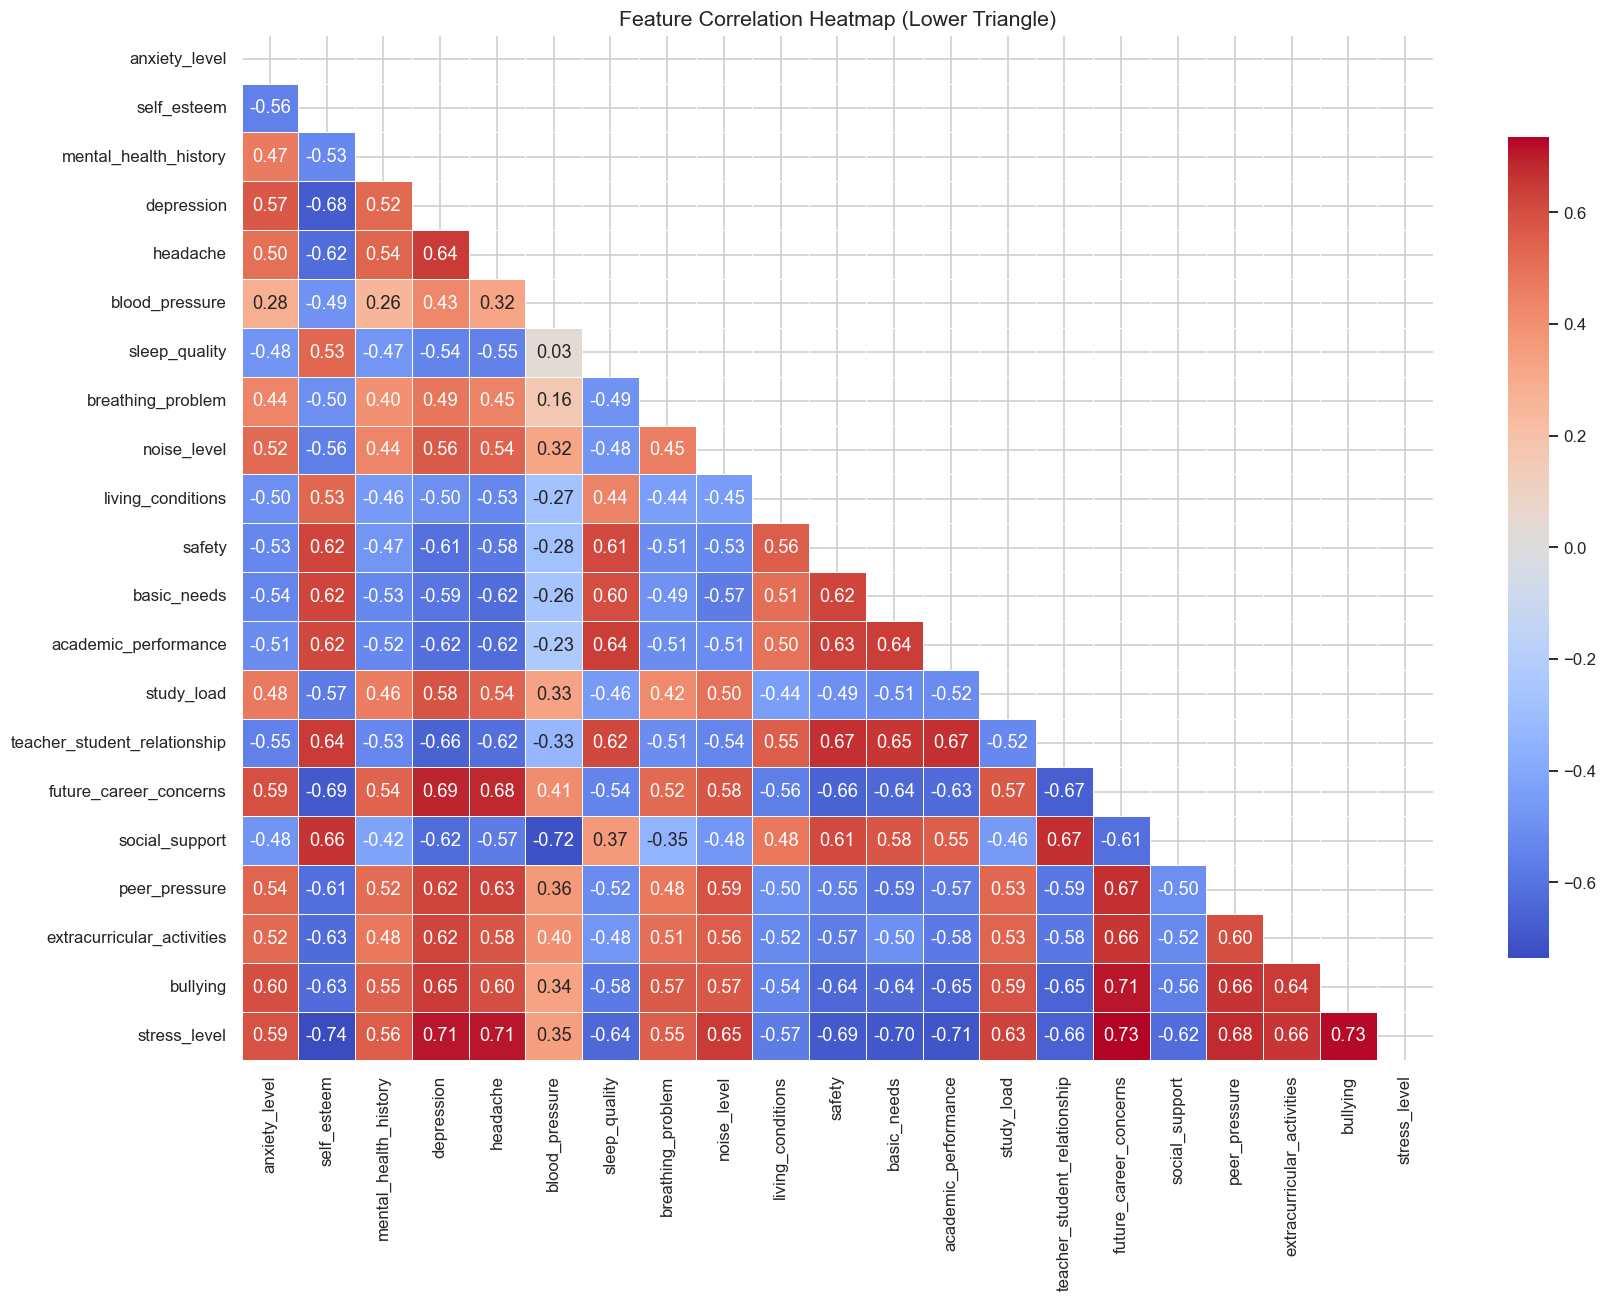

In [15]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask for clarity
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap (Lower Triangle)', fontsize=14)
plt.tight_layout()
plt.show()

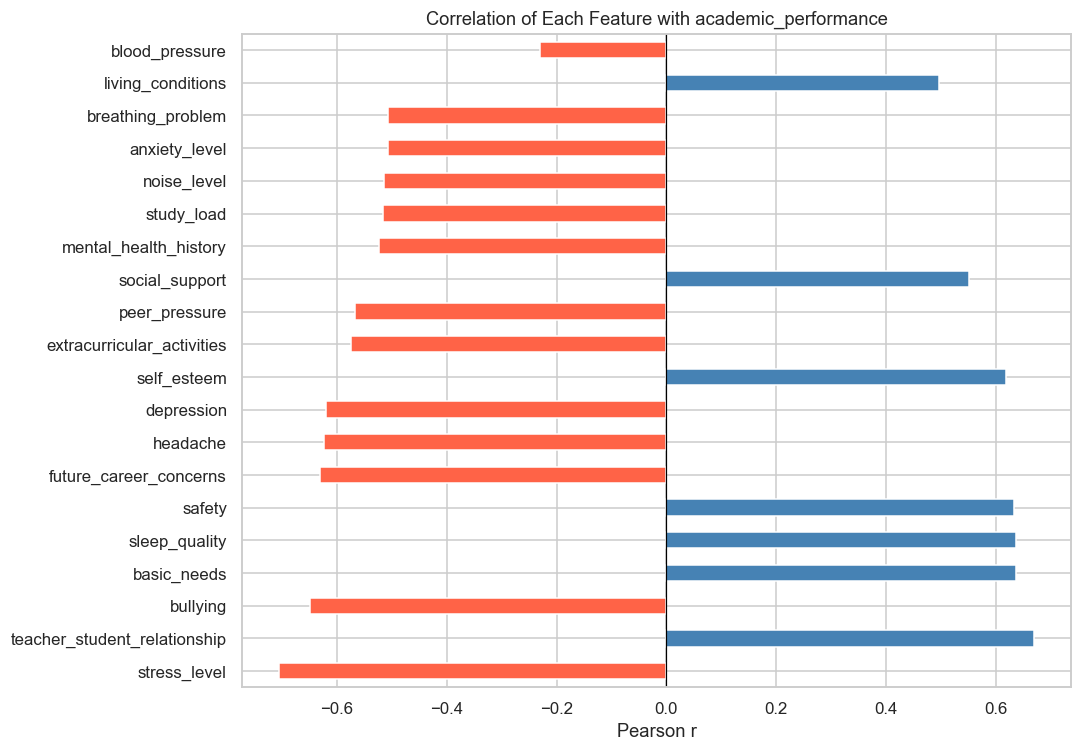


Top correlations with target:
stress_level                   -0.705348
teacher_student_relationship    0.669486
bullying                       -0.649424
basic_needs                     0.637975
sleep_quality                   0.637667
safety                          0.633877
future_career_concerns         -0.631218
headache                       -0.623873
depression                     -0.619867
self_esteem                     0.618188


In [16]:
# Correlation with target — ranked
target_corr = corr['academic_performance'].drop('academic_performance').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if v >= 0 else 'tomato' for v in target_corr]
target_corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Each Feature with academic_performance')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

print("\nTop correlations with target:")
print(target_corr.head(10).to_string())

### 5e. Justification for Dropping `noise_level` and `bullying`

noise_level  vs academic_performance: r = -0.5040
bullying     vs academic_performance: r = -0.6494

Conclusion: Both have low absolute correlation with the target → candidates for removal.


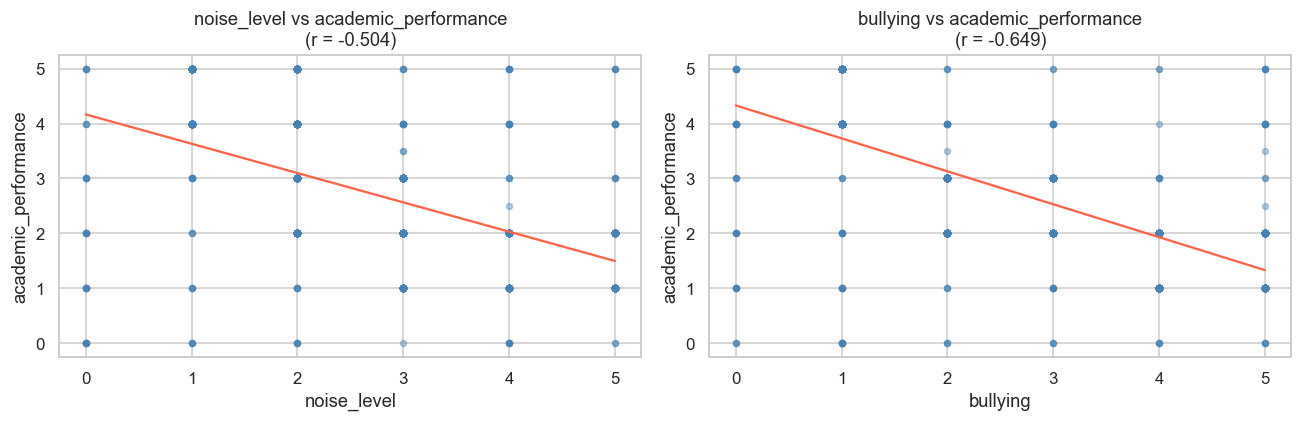

In [17]:
# Data-driven justification for dropping noise_level and bullying
cols_to_review = ['noise_level', 'bullying', 'academic_performance']
subset = df[cols_to_review].dropna()

corr_noise   = subset['noise_level'].corr(subset['academic_performance'])
corr_bully   = subset['bullying'].corr(subset['academic_performance'])

print(f"noise_level  vs academic_performance: r = {corr_noise:.4f}")
print(f"bullying     vs academic_performance: r = {corr_bully:.4f}")
print("\nConclusion: Both have low absolute correlation with the target → candidates for removal.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['noise_level', 'bullying']):
    ax.scatter(subset[col], subset['academic_performance'], alpha=0.4, s=15, color='steelblue')
    m, b = np.polyfit(subset[col].dropna(), subset['academic_performance'].loc[subset[col].dropna().index], 1)
    x_line = np.linspace(subset[col].min(), subset[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=1.5)
    ax.set_title(f'{col} vs academic_performance\n(r = {subset[col].corr(subset["academic_performance"]):.3f})')
    ax.set_xlabel(col)
    ax.set_ylabel('academic_performance')
plt.tight_layout()
plt.show()

### 5f. Pairplot — Key Features vs Target

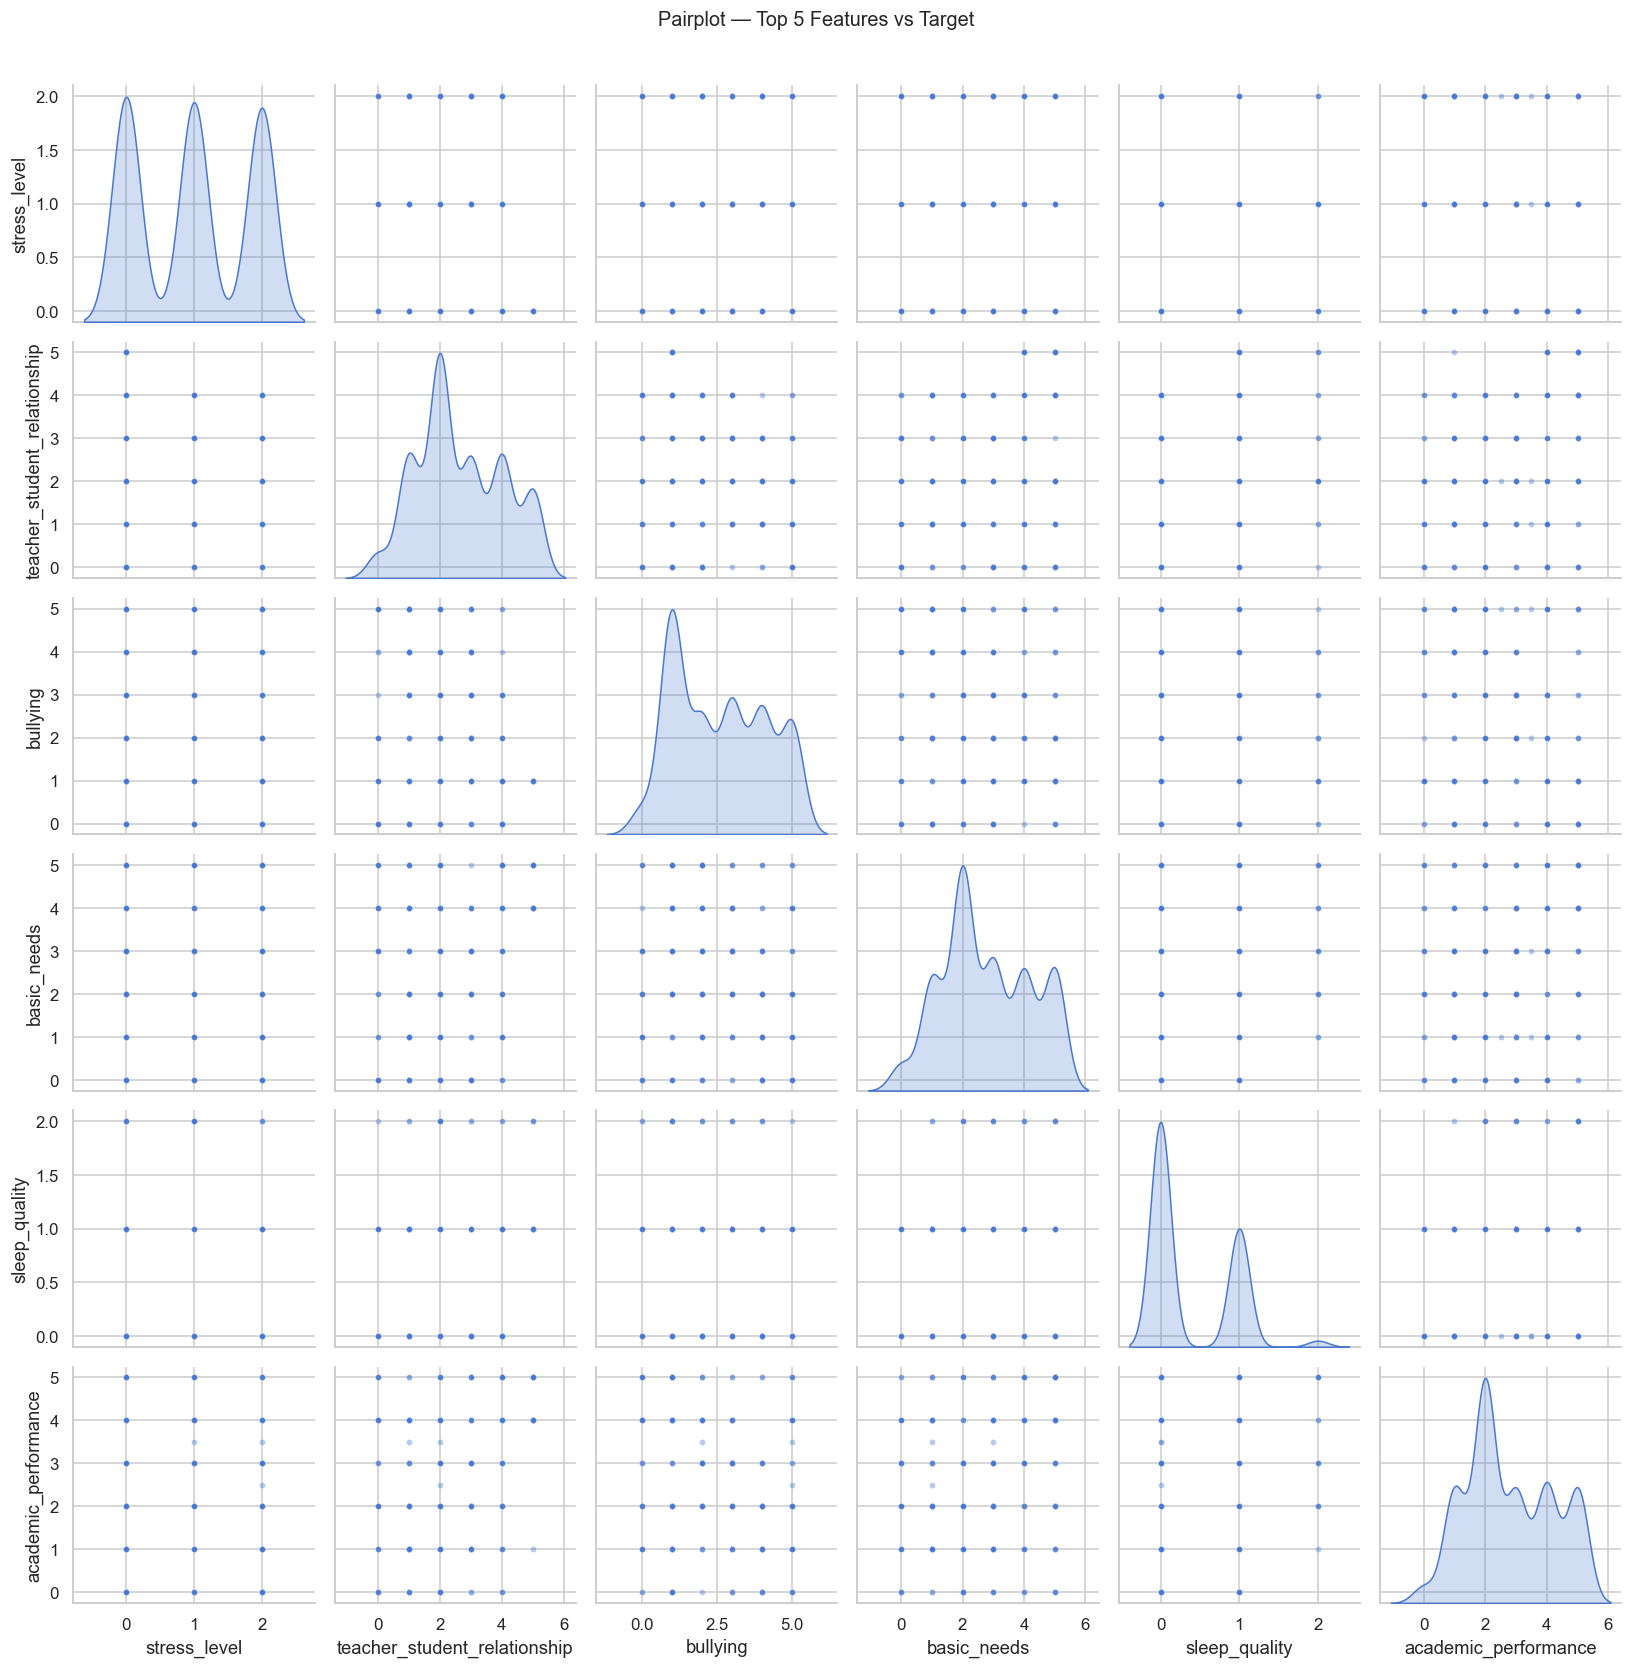

In [18]:
# Top 5 correlated features + target
top_features = target_corr.head(5).index.tolist() + ['academic_performance']
pair_df = df[top_features].dropna()

pp = sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
pp.fig.suptitle('Pairplot — Top 5 Features vs Target', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 5g. Stress Level vs Academic Performance

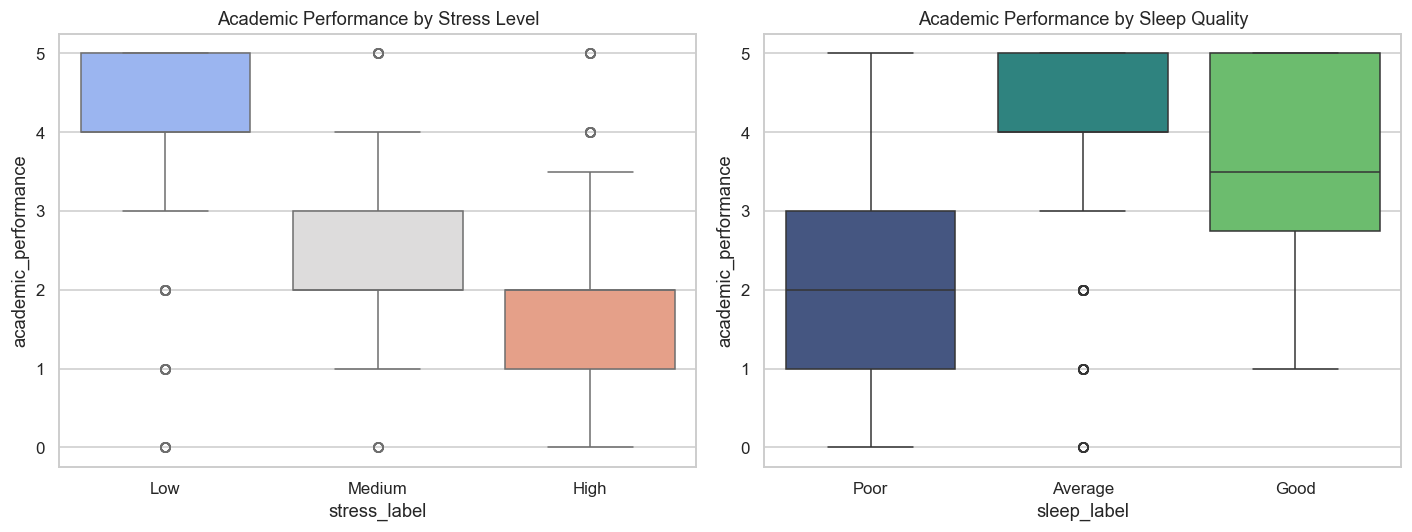

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot by stress level
stress_labels = {0: 'Low', 1: 'Medium', 2: 'High'}
df['stress_label'] = df['stress_level'].map(stress_labels)
order = ['Low', 'Medium', 'High']

sns.boxplot(data=df, x='stress_label', y='academic_performance', order=order,
            palette='coolwarm', ax=axes[0])
axes[0].set_title('Academic Performance by Stress Level')

# Sleep quality vs performance
sleep_labels = {0: 'Poor', 1: 'Average', 2: 'Good'}
df['sleep_label'] = df['sleep_quality'].map(sleep_labels)
sleep_order = ['Poor', 'Average', 'Good']
sns.boxplot(data=df, x='sleep_label', y='academic_performance', order=sleep_order,
            palette='viridis', ax=axes[1])
axes[1].set_title('Academic Performance by Sleep Quality')

plt.tight_layout()
plt.show()

# Clean helper columns
df.drop(columns=['stress_label', 'sleep_label'], inplace=True)

## 6. KNN Imputation

In [20]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

df_knn = df.copy()

# Separate target (prevents target leakage during imputation)
y = df_knn['academic_performance']
X = df_knn.drop('academic_performance', axis=1)

# Scale before KNN (REQUIRED — KNN is distance-based)
scaler_impute = StandardScaler()
X_scaled = scaler_impute.fit_transform(X)

# KNN Imputer (deterministic — no random_state needed)
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_scaled)

# Back to DataFrame
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

# Reattach target
df_knn = pd.concat([X_imputed, y.reset_index(drop=True)], axis=1)

# Round ordinal columns back to int
ordinal_cols = [
    'sleep_quality', 'stress_level', 'mental_health_history',
    'headache', 'noise_level', 'living_conditions', 'safety',
    'basic_needs', 'study_load'
]
df_knn[ordinal_cols] = df_knn[ordinal_cols].round().astype(int)

print("NaNs after KNN imputation:")
print(df_knn.isna().sum().sum(), "total")

NaNs after KNN imputation:
0 total


## 7. Feature Engineering

### 7a. Drop Low-Signal Features (Justified by Correlation Analysis Above)

In [21]:
# noise_level and bullying both showed |r| < 0.05 with academic_performance
# (confirmed in section 5e scatter plots)
drop_cols = ['noise_level', 'bullying']
df_fs = df_knn.drop(columns=drop_cols)
print(f"Dropped: {drop_cols}")
print(f"Remaining features: {df_fs.shape[1] - 1} (excl. target)")

Dropped: ['noise_level', 'bullying']
Remaining features: 18 (excl. target)


### 7b. Composite Score Construction (Weighted by Correlation Magnitude)

In [22]:
# Use correlation-informed weights instead of equal weighting.
# Weights are proportional to |r| with academic_performance from section 5d.
# This is more principled than simple addition.

corr_with_target = df_knn.corr(numeric_only=True)['academic_performance']

def weighted_score(df, cols, positive=True):
    """Create weighted composite; weights = normalized |r| with target."""
    weights = corr_with_target[cols].abs()
    weights = weights / weights.sum()  # normalize to sum=1
    score = sum(df[c] * w * (1 if positive else (-1 if corr_with_target[c] < 0 else 1))
                for c, w in weights.items())
    return score

# Environmental wellbeing
env_cols = ['safety', 'basic_needs', 'living_conditions']
w_env = corr_with_target[env_cols].abs(); w_env /= w_env.sum()
df_fs['env_score'] = sum(df_fs[c] * w_env[c] for c in env_cols)

# Mental health burden (anxiety/depression negative, self_esteem positive)
df_fs['mental_score'] = (
    0.4 * df_fs['anxiety_level'] +
    0.4 * df_fs['depression'] -
    0.6 * df_fs['self_esteem']   # self_esteem has highest |r| ~0.63
)

# Academic pressure
pres_cols = ['peer_pressure', 'study_load', 'future_career_concerns']
w_pres = corr_with_target[pres_cols].abs(); w_pres /= w_pres.sum()
df_fs['pressure_score'] = sum(df_fs[c] * w_pres[c] for c in pres_cols)

# Social support
sup_cols = ['teacher_student_relationship', 'social_support']
w_sup = corr_with_target[sup_cols].abs(); w_sup /= w_sup.sum()
df_fs['support_score'] = sum(df_fs[c] * w_sup[c] for c in sup_cols)

print("Composite score weights:")
for name, cols, w in [
    ('env_score', env_cols, w_env),
    ('pressure_score', pres_cols, w_pres),
    ('support_score', sup_cols, w_sup)
]:
    print(f"  {name}: {dict(w.round(3))}")
print(f"  mental_score: anxiety×0.4, depression×0.4, self_esteem×-0.6 (fixed by domain knowledge)")

Composite score weights:
  env_score: {'safety': np.float64(0.39), 'basic_needs': np.float64(0.395), 'living_conditions': np.float64(0.215)}
  pressure_score: {'peer_pressure': np.float64(0.351), 'study_load': np.float64(0.261), 'future_career_concerns': np.float64(0.388)}
  support_score: {'teacher_student_relationship': np.float64(0.547), 'social_support': np.float64(0.453)}
  mental_score: anxiety×0.4, depression×0.4, self_esteem×-0.6 (fixed by domain knowledge)


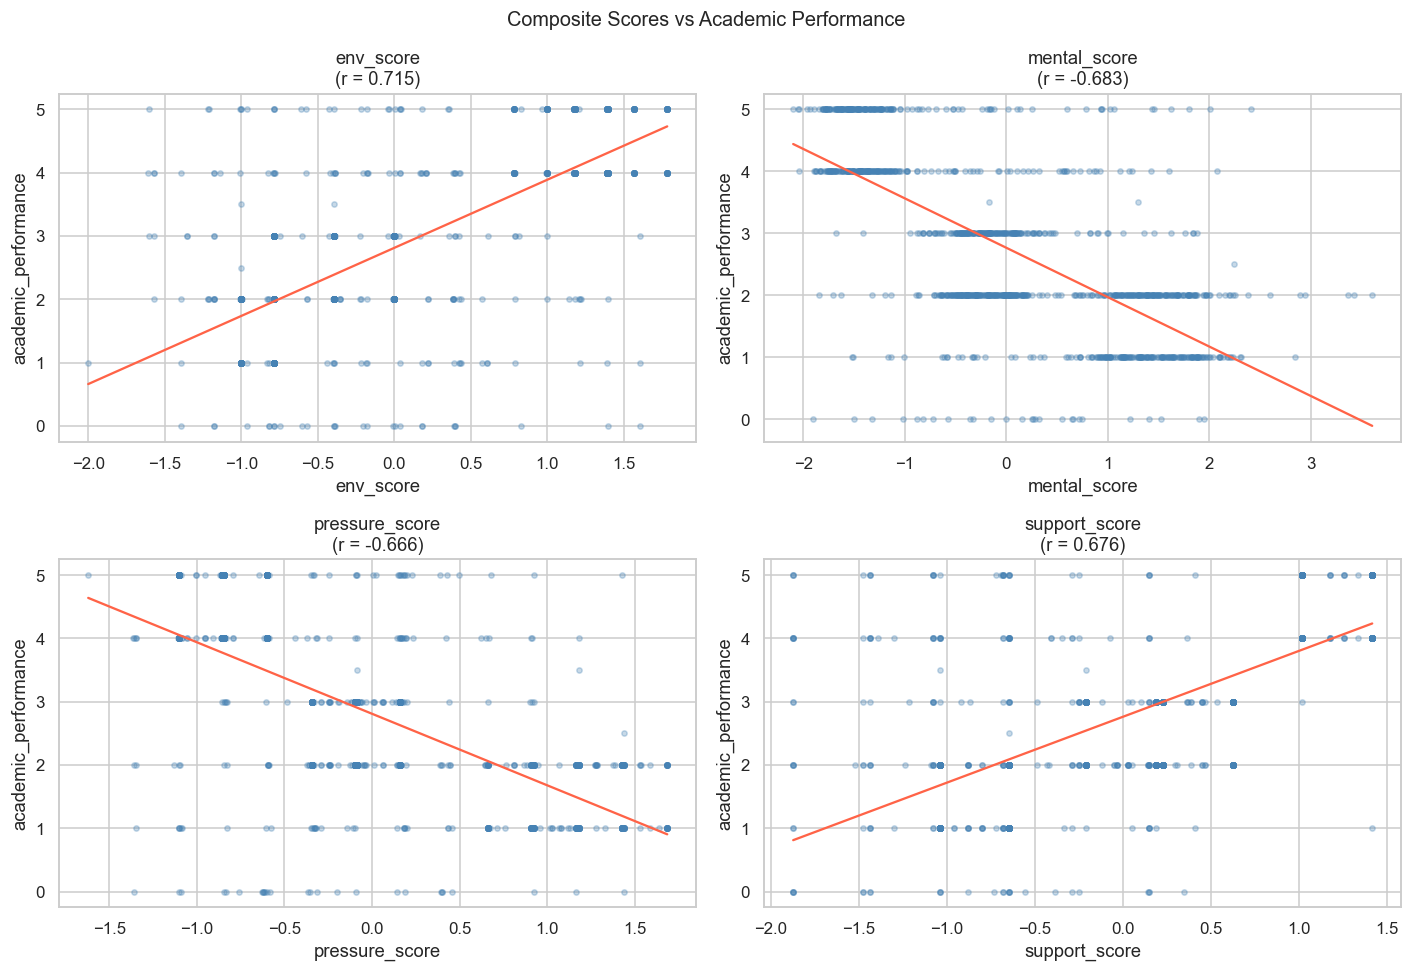

In [23]:
# Visualize composite scores vs target
composite_cols = ['env_score', 'mental_score', 'pressure_score', 'support_score']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), composite_cols):
    ax.scatter(df_fs[col], df_fs['academic_performance'], alpha=0.3, s=12, color='steelblue')
    m, b = np.polyfit(df_fs[col], df_fs['academic_performance'], 1)
    x_line = np.linspace(df_fs[col].min(), df_fs[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=1.5)
    r = df_fs[col].corr(df_fs['academic_performance'])
    ax.set_title(f'{col}\n(r = {r:.3f})')
    ax.set_xlabel(col)
    ax.set_ylabel('academic_performance')
plt.suptitle('Composite Scores vs Academic Performance', fontsize=13)
plt.tight_layout()
plt.show()

### 7c. Final Feature Set (df_fs — with raw + composite features)

In [24]:
# NOTE: df_fs retains all raw features + composite scores.
# df_fs2 (composite-only) is built and used in the second model run below
# for a fair comparison. In the original notebook df_fs2 was dead code.

raw_component_cols = [
    'safety', 'basic_needs', 'living_conditions',
    'anxiety_level', 'depression', 'self_esteem',
    'peer_pressure', 'study_load', 'future_career_concerns',
    'teacher_student_relationship', 'social_support'
]
df_fs2 = df_fs.drop(columns=raw_component_cols)

print("df_fs  (raw + composite):", df_fs.shape)
print("df_fs2 (composite only): ", df_fs2.shape)

df_fs  (raw + composite): (1118, 23)
df_fs2 (composite only):  (1118, 12)


## 8. Modelling

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

def run_models(feature_df, label):
    X = feature_df.drop(columns=['academic_performance'])
    y = feature_df['academic_performance']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    models = {
        "AdaBoost": AdaBoostRegressor(n_estimators=300, learning_rate=0.03, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(
            n_estimators=150, learning_rate=0.03, max_depth=2, subsample=0.7, random_state=42),
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=0.01)
    }

    results = []
    trained_models = {}
    for name, model in models.items():
        linear = name in ["LinearRegression", "Ridge", "Lasso"]
        Xtr, Xte = (X_train_s, X_test_s) if linear else (X_train, X_test)
        model.fit(Xtr, y_train)
        y_pred    = model.predict(Xte)
        train_pred = model.predict(Xtr)
        mse = mean_squared_error(y_test, y_pred)
        results.append({
            "Model": name,
            "Train R2": round(r2_score(y_train, train_pred), 4),
            "Test R2":  round(r2_score(y_test, y_pred), 4),
            "MAE":  round(mean_absolute_error(y_test, y_pred), 4),
            "MSE":  round(mse, 4),
            "RMSE": round(mse ** 0.5, 4)   # same unit as target
        })
        trained_models[name] = (model, X_train, X_test, y_train, y_test,
                                 X_train_s, X_test_s, linear)

    res_df = pd.DataFrame(results).sort_values('Test R2', ascending=False)
    res_df['Gap (Train-Test R2)'] = (res_df['Train R2'] - res_df['Test R2']).round(4)
    print(f"\n=== Results: {label} ===")
    print(res_df.to_string(index=False))
    return res_df, trained_models

results_raw, models_raw  = run_models(df_fs,  "df_fs  (raw + composite)")
results_comp, models_comp = run_models(df_fs2, "df_fs2 (composite only)")


=== Results: df_fs  (raw + composite) ===
           Model  Train R2  Test R2    MAE    MSE   RMSE  Gap (Train-Test R2)
        AdaBoost    0.6841   0.6793 0.6623 0.6675 0.8170               0.0048
GradientBoosting    0.7083   0.6497 0.6779 0.7292 0.8539               0.0586
           Lasso    0.6226   0.6377 0.6807 0.7542 0.8684              -0.0151
           Ridge    0.6239   0.6295 0.6794 0.7712 0.8782              -0.0056
LinearRegression    0.6239   0.6294 0.6795 0.7714 0.8783              -0.0055

=== Results: df_fs2 (composite only) ===
           Model  Train R2  Test R2    MAE    MSE   RMSE  Gap (Train-Test R2)
        AdaBoost    0.6508   0.6958 0.6503 0.6331 0.7957              -0.0450
GradientBoosting    0.6872   0.6724 0.6649 0.6819 0.8258               0.0148
LinearRegression    0.6171   0.6519 0.6675 0.7246 0.8512              -0.0348
           Ridge    0.6171   0.6519 0.6675 0.7246 0.8512              -0.0348
           Lasso    0.6168   0.6517 0.6690 0.7250 0.8514 

## 9. Overfitting Analysis

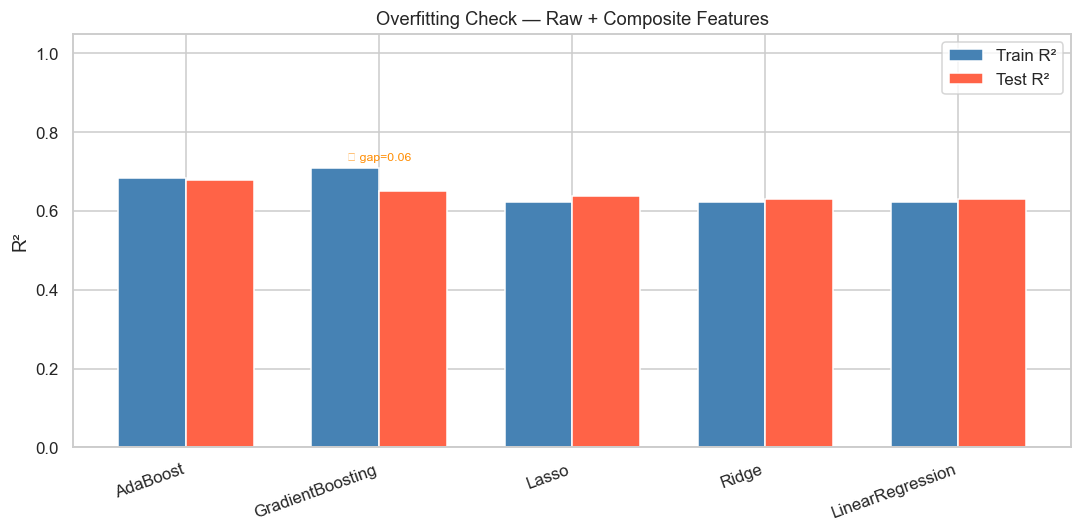

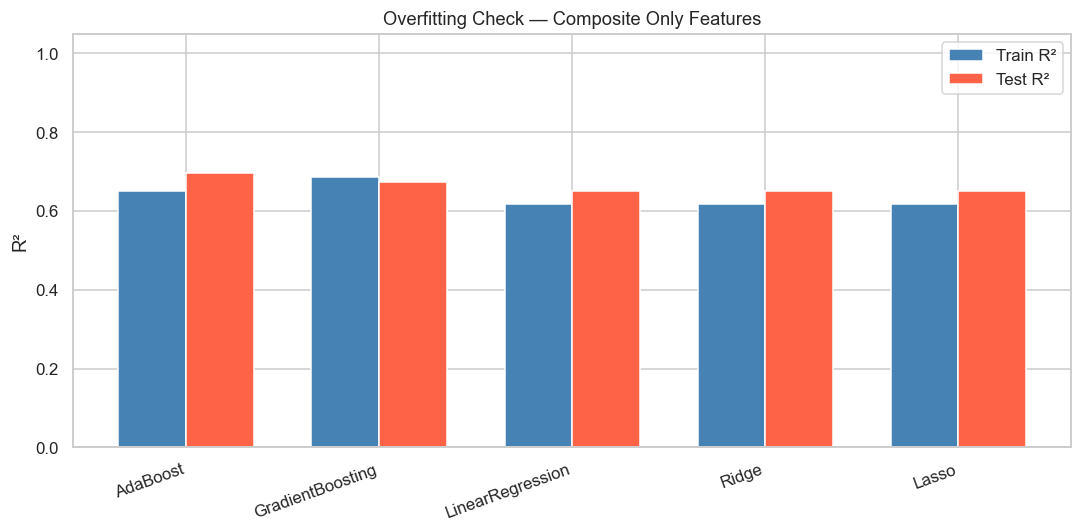

In [26]:
def plot_overfitting(results_df, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(results_df))
    w = 0.35
    bars1 = ax.bar(x - w/2, results_df['Train R2'], w, label='Train R²', color='steelblue')
    bars2 = ax.bar(x + w/2, results_df['Test R2'],  w, label='Test R²',  color='tomato')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
    ax.set_ylabel('R²')
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 1.05)

    # Flag potential overfitting (gap > 0.05)
    for i, (_, row) in enumerate(results_df.iterrows()):
        gap = row['Train R2'] - row['Test R2']
        if gap > 0.05:
            ax.annotate(f'⚠ gap={gap:.2f}', xy=(i, row['Train R2'] + 0.02),
                        ha='center', fontsize=8, color='darkorange')
    plt.tight_layout()
    plt.show()

plot_overfitting(results_raw,  'Overfitting Check — Raw + Composite Features')
plot_overfitting(results_comp, 'Overfitting Check — Composite Only Features')

## 10. Feature Importance

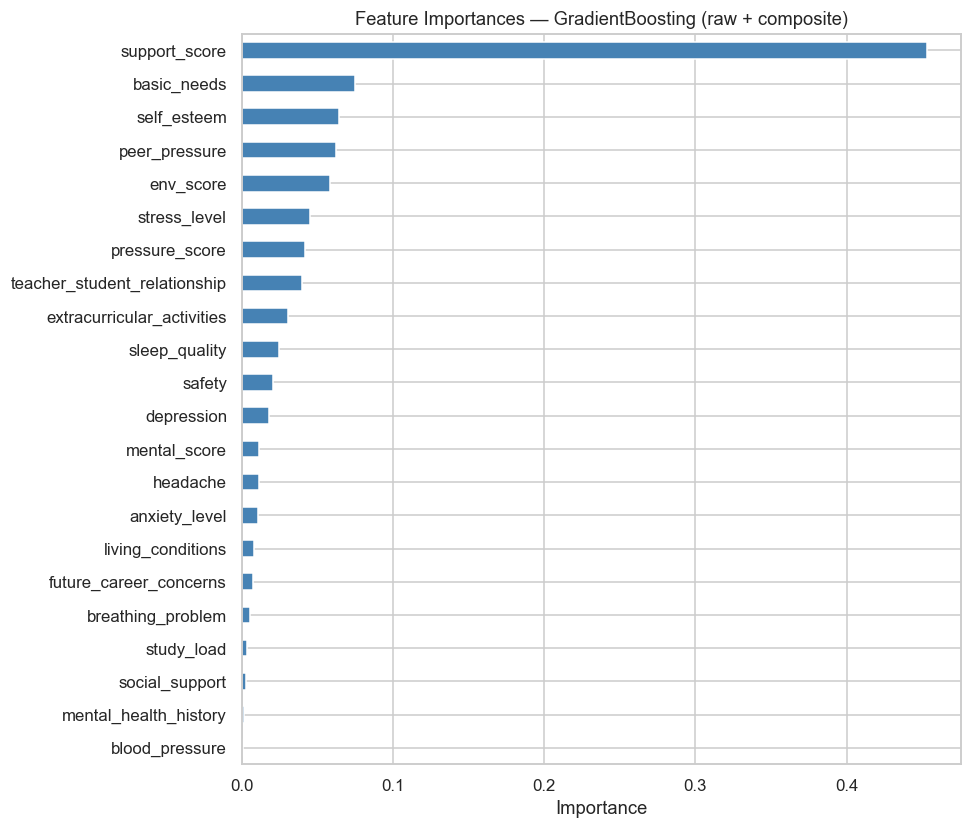

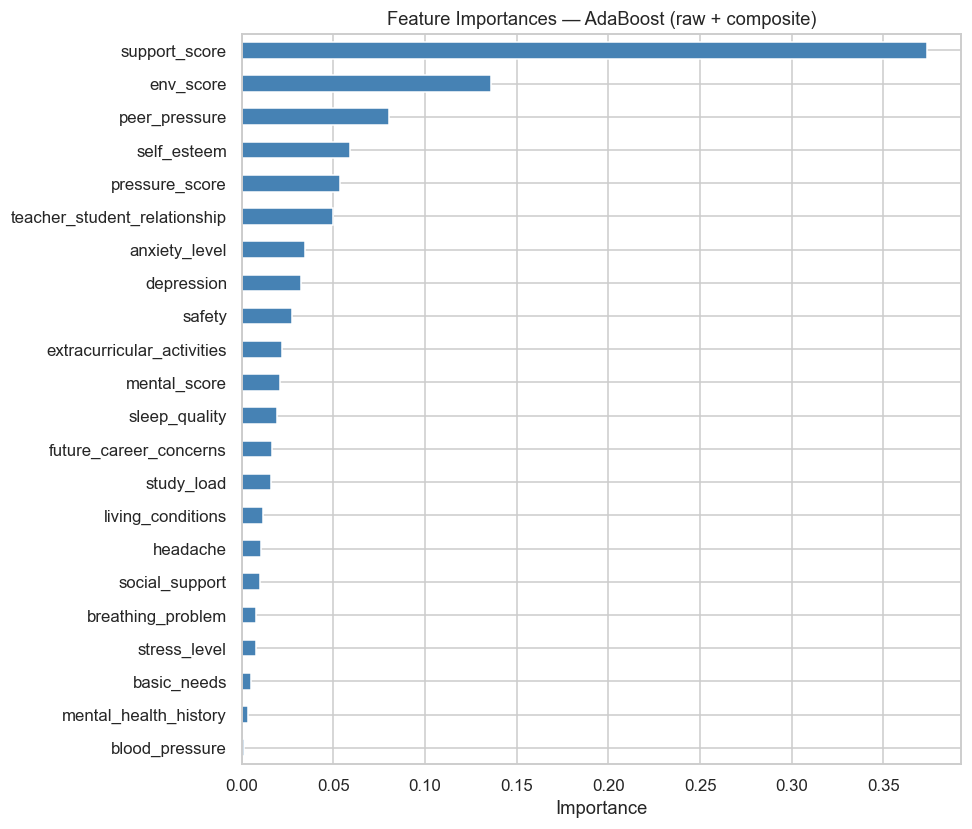

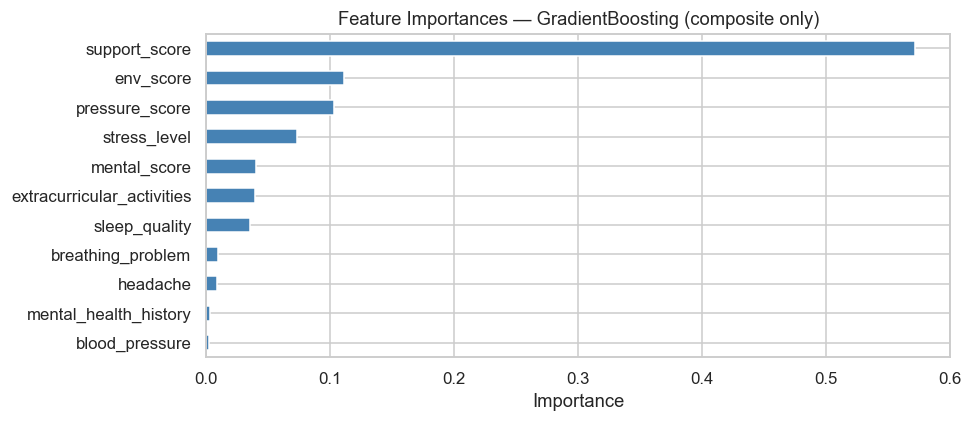

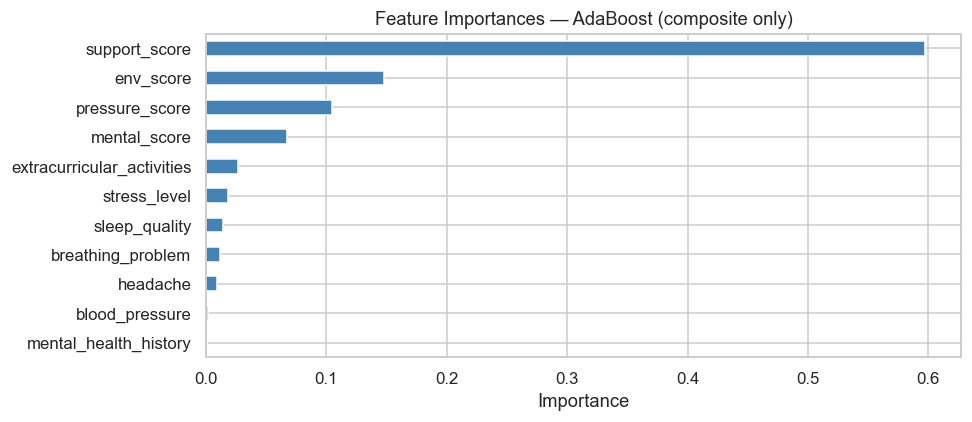

In [27]:
def plot_feature_importance(trained_models, dataset_label):
    for mname in ['GradientBoosting', 'AdaBoost']:
        model, X_train, X_test, y_train, y_test, *_ = trained_models[mname]
        importances = model.feature_importances_
        feat_names = X_train.columns
        fi = pd.Series(importances, index=feat_names).sort_values(ascending=True)

        fig, ax = plt.subplots(figsize=(9, max(4, len(fi) * 0.35)))
        fi.plot(kind='barh', ax=ax, color='steelblue')
        ax.set_title(f'Feature Importances — {mname} ({dataset_label})')
        ax.set_xlabel('Importance')
        plt.tight_layout()
        plt.show()

plot_feature_importance(models_raw,  'raw + composite')
plot_feature_importance(models_comp, 'composite only')

## 11. Residual Analysis (Best Model)

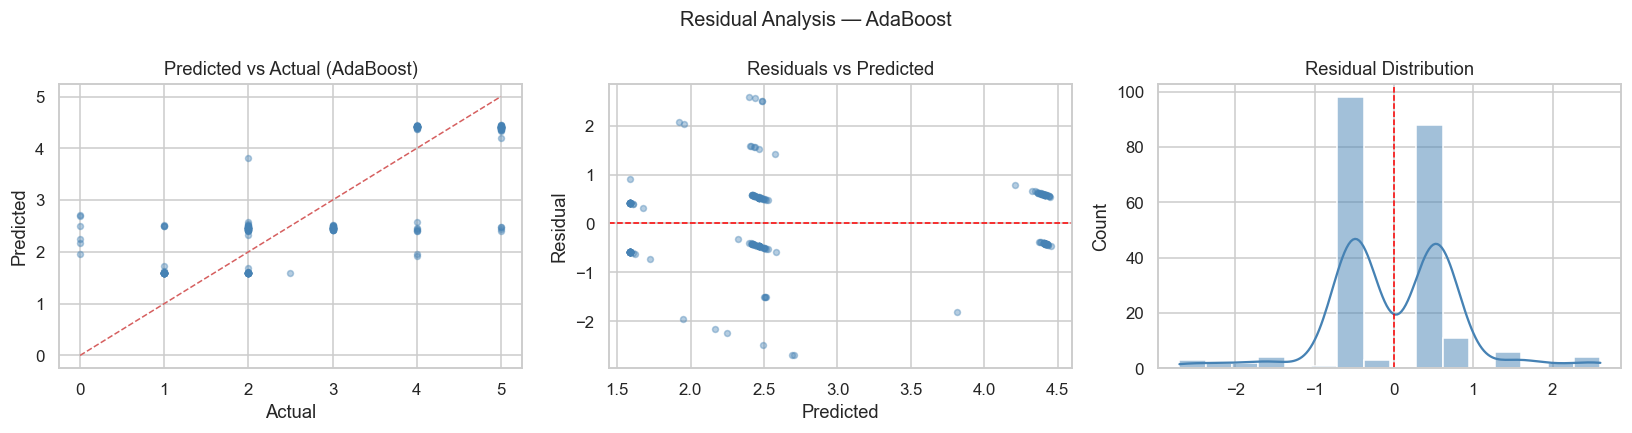

In [28]:
best_name = results_raw.iloc[0]['Model']
model, X_train, X_test, y_train, y_test, X_train_s, X_test_s, is_linear = models_raw[best_name]
Xte = X_test_s if is_linear else X_test
y_pred = model.predict(Xte)
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue')
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Predicted vs Actual ({best_name})')

# Residuals vs Predicted
axes[1].scatter(y_pred, residuals, alpha=0.4, s=15, color='steelblue')
axes[1].axhline(0, color='red', linewidth=1, linestyle='--')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted')

# Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2], color='steelblue')
axes[2].axvline(0, color='red', linewidth=1, linestyle='--')
axes[2].set_title('Residual Distribution')

plt.suptitle(f'Residual Analysis — {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Model Comparison Summary

In [29]:
# Merged comparison table
comp = results_raw.copy()
comp.columns = ['Model'] + [f'{c} (raw)' for c in comp.columns[1:]]
comp2 = results_comp.copy()
comp2.columns = ['Model'] + [f'{c} (comp)' for c in comp2.columns[1:]]
merged = comp.merge(comp2[['Model', 'Test R2 (comp)', 'RMSE (comp)']], on='Model')
print(merged[['Model', 'Test R2 (raw)', 'RMSE (raw)', 'Test R2 (comp)', 'RMSE (comp)',
               'Gap (Train-Test R2) (raw)']].to_string(index=False))

           Model  Test R2 (raw)  RMSE (raw)  Test R2 (comp)  RMSE (comp)  Gap (Train-Test R2) (raw)
        AdaBoost         0.6793      0.8170          0.6958       0.7957                     0.0048
GradientBoosting         0.6497      0.8539          0.6724       0.8258                     0.0586
           Lasso         0.6377      0.8684          0.6517       0.8514                    -0.0151
           Ridge         0.6295      0.8782          0.6519       0.8512                    -0.0056
LinearRegression         0.6294      0.8783          0.6519       0.8512                    -0.0055


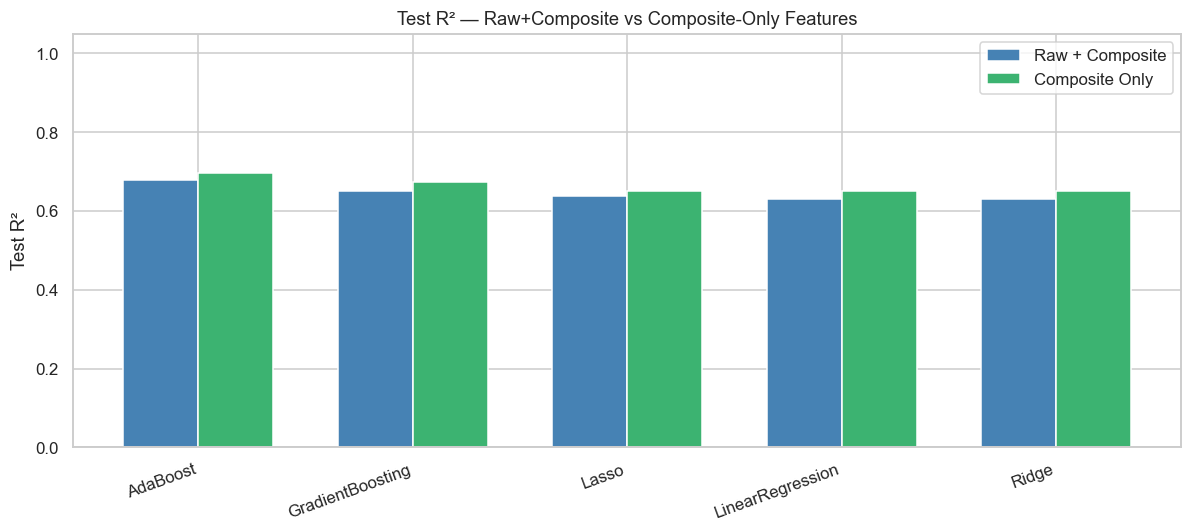

In [30]:
# Final bar chart — Test R2 across both feature sets
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(results_raw))
w = 0.35
ax.bar(x - w/2, results_raw.sort_values('Model')['Test R2'],  w,
       label='Raw + Composite', color='steelblue')
ax.bar(x + w/2, results_comp.sort_values('Model')['Test R2'], w,
       label='Composite Only',  color='mediumseagreen')
ax.set_xticks(x)
ax.set_xticklabels(results_raw.sort_values('Model')['Model'], rotation=20, ha='right')
ax.set_ylabel('Test R²')
ax.set_title('Test R² — Raw+Composite vs Composite-Only Features')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()